TokaMaker Example: Synthetic Magnetic Diagnostics for the CUTE Tokamak {#doc_tMaker_CUTE_ex4}
==========

A tokamak plasma cannot be photographed. Everything we claim to know about its
shape and current comes from sensors **outside** the vessel, reading the
magnetic field the plasma leaves behind. Equilibrium reconstruction is the
inverse problem: given those readings, infer the plasma that produced them.

Before you can solve that inverse problem, you need the forward one. This
notebook builds the forward map for CUTE:

$$\text{plasma equilibrium} \;\longrightarrow\; \text{what each magnetic sensor reads}$$

Two sensor types do the work.

**(a) Flux loops.** A wire loop encircling the machine toroidally at a fixed
$(R, Z)$. The voltage induced in it integrates to the poloidal flux $\psi$
threading that loop, so a flux loop is a direct probe of $\psi$ at a point.

**(b) Mirnov probes.** A small coil measuring the *local* magnetic field. It
responds to the field component along its own orientation, so a probe at angle
$\theta$ reads
$$B_\theta = B_R\cos\theta + B_Z\sin\theta.$$
Mirnov probes see the poloidal field directly, which makes them sensitive to
where the current sits.

The other TokaMaker examples go from targets to an equilibrium
(`CUTE_null_ex`, `CUTE_pulse_ex`) or reconstruct using shape constraints
(`ITER_reconstruction_ex`). None of them simulates a sensor. This notebook adds
that missing step, which is what makes noise, sensor loss, and machine learning
surrogates possible to study.

**Why this matters for a machine that is not running.** CUTE is not currently
operating, so there is no measured data to work from. That is exactly when a
synthetic diagnostic model earns its keep: it lets you design the diagnostic
set, test the reconstruction, and understand its failure modes before hardware
exists.

## Setup Python environment

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np

# Run from the repository root so `src` is importable.
REPO_ROOT = os.path.abspath("..")
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from OpenFUSIONToolkit import OFT_env
from OpenFUSIONToolkit.TokaMaker import TokaMaker
from OpenFUSIONToolkit.TokaMaker.meshing import load_gs_mesh
from OpenFUSIONToolkit.TokaMaker.util import create_isoflux, create_power_flux_fun

from src.forward.model import full_diagnostic_set
from src.forward.sensors import generate_cute_sensors

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## Setup model

### Initialize TokaMaker and load the CUTE mesh

Identical to `CUTE_mesh_ex`: the mesh carries the vacuum vessel, the 14 CS and
14 PF coil sets, and the region tags TokaMaker needs. For CUTE the limiter is
the inner surface of the vessel.

In [2]:
myOFT = OFT_env(nthreads=2)
mygs = TokaMaker(myOFT)

mesh_pts, mesh_lc, mesh_reg, coil_dict, cond_dict = load_gs_mesh(
    os.path.join(REPO_ROOT, "data", "CUTE_mesh.h5")
)
mygs.setup_mesh(mesh_pts, mesh_lc, mesh_reg)
mygs.setup_regions(cond_dict=cond_dict, coil_dict=coil_dict)

mygs.settings.lim_zmax = 0.38
mygs.settings.pm = False
mygs.setup(order=2, F0=0.17)

# CUTE coils are limited to 1 kA per turn.
mygs.set_coil_bounds({key: [-1.0e3, 1.0e3] for key in mygs.coil_sets})
print(f"{len(mygs.coil_sets)} coil sets loaded")

#----------------------------------------------
Open FUSION Toolkit Initialized
Development branch:    main
Revision id:           b19540a
Parallelization Info:
  Not compiled with MPI
  # of OpenMP threads =    2
Fortran input file    = /var/folders/dp/643386y10pg0wlcjl4xc3s7m0000gp/T/oft_72710/oftpyin
XML input file        = none
Integer Precisions    =    4   8
Float Precisions      =    4   8  16
Complex Precisions    =    4   8
LA backend            = native
#----------------------------------------------


**** Loading OFT surface mesh

**** Generating surface grid level  1
  Generating boundary domain linkage
  Mesh statistics:
    Area         =  1.301E+00
    # of points  =    5796
    # of edges   =   17283
    # of cells   =   11488
    # of boundary points =     102
    # of boundary edges  =     102
    # of boundary cells  =     102
  Resolution statistics:
    hmin =  3.994E-03
    hrms =  1.721E-02
    hmax =  7.410E-02
  Surface grounded at vertex     761


**** Creati

28 coil sets loaded


## Compute a reference equilibrium

We need a plasma to measure. This is a routine limited equilibrium near the
middle of CUTE's operating space: $I_p = 100$ kA, $R_0 = 0.32$ m, $a = 0.17$ m,
elongation $\kappa = 1.7$, triangularity $\delta = 0.4$.

Nothing about the diagnostics depends on this particular choice. It is simply
the plasma we will measure first.

In [3]:
mygs.set_profiles(ffp_prof=create_power_flux_fun(40, 1.5, 2.0),
                  pp_prof=create_power_flux_fun(40, 4.0, 1.0))

R0, Z0, a, kappa, delta = 0.32, 0.0, 0.17, 1.7, 0.4

isoflux_pts = create_isoflux(80, R0, Z0, a, kappa, delta)
isoflux_pts = isoflux_pts[isoflux_pts[:, 0] > 0.3, :]
isoflux_pts = np.vstack((isoflux_pts, np.array([[0.15, 0.0]])))
x_points = np.array([[0.22, -0.33], [0.20, 0.34]])

mygs.set_saddles(x_points)
mygs.set_isoflux(np.vstack((isoflux_pts, x_points)))
mygs.set_targets(Ip=1.0e5, Ip_ratio=4.0)
mygs.init_psi(R0, Z0, 0.13, kappa, delta)
mygs.solve()

stats = mygs.get_stats()
print(f"Ip      = {stats['Ip'] / 1e3:8.1f} kA")
print(f"R_geo   = {stats['R_geo']:8.4f} m")
print(f"a_geo   = {stats['a_geo']:8.4f} m")
print(f"kappa   = {stats['kappa']:8.3f}")
print(f"q_95    = {stats['q_95']:8.3f}")

Ip      =    100.0 kA
R_geo   =   0.3156 m
a_geo   =   0.1744 m
kappa   =    1.888
q_95    =    8.166


## The diagnostic set

CUTE's assumed diagnostic set here is **130 sensors**: 56 flux loops and 74
Mirnov probes, distributed inboard, outboard, top and bottom.

**Caveat on the sensor set:** this layout is a plausible reconstruction of what
such a machine would carry, not the installed CUTE diagnostic set. Every
downstream number inherits that assumption. Replacing
`generate_cute_sensors()` with the real geometry is the single highest-value
substitution available in this notebook.

flux loops     : 56
Mirnov probes  : 74
total channels : 130


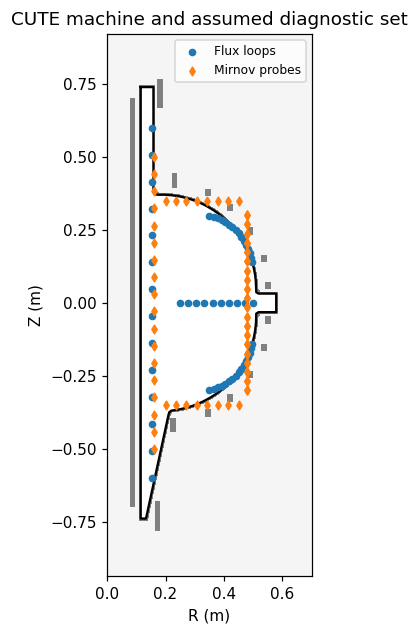

In [4]:
sensors = generate_cute_sensors()
print(f"flux loops     : {sensors.n_flux_loops}")
print(f"Mirnov probes  : {sensors.n_mirnov_probes}")
print(f"total channels : {sensors.n_total}")

fl_R = np.array([s["R"] for s in sensors.flux_loops])
fl_Z = np.array([s["Z"] for s in sensors.flux_loops])
mp_R = np.array([s["R"] for s in sensors.mirnov_probes])
mp_Z = np.array([s["Z"] for s in sensors.mirnov_probes])

fig, ax = plt.subplots(1, 1, figsize=(5.0, 6.4))
mygs.plot_machine(fig, ax, coil_colormap=None, limiter_color="k")
ax.scatter(fl_R, fl_Z, s=16, marker="o", label="Flux loops", zorder=5)
ax.scatter(mp_R, mp_Z, s=16, marker="d", label="Mirnov probes", zorder=5)
ax.set_xlabel("R (m)"); ax.set_ylabel("Z (m)")
ax.set_title("CUTE machine and assumed diagnostic set")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## Evaluate the forward model

For the solved equilibrium, evaluate $\psi$ at each flux loop and the oriented
field component at each Mirnov probe. This is the forward map: one equilibrium
in, 130 numbers out.

In [5]:
frame = full_diagnostic_set(mygs, sensors)
channels = [c for c in frame.columns if c != "time"]
signals = frame[channels].to_numpy(dtype=float)[0]

is_loop = np.array([c.startswith("FL_") for c in channels])

print(f"signal vector: {signals.shape[0]} channels")
print(f"  flux loops  [Wb] : {signals[is_loop].min(): .3e} .. {signals[is_loop].max(): .3e}")
print(f"  Mirnov      [T]  : {signals[~is_loop].min(): .3e} .. {signals[~is_loop].max(): .3e}")

signal vector: 130 channels
  flux loops  [Wb] : -3.204e-03 ..  9.562e-03
  Mirnov      [T]  : -1.572e-01 ..  1.775e-01


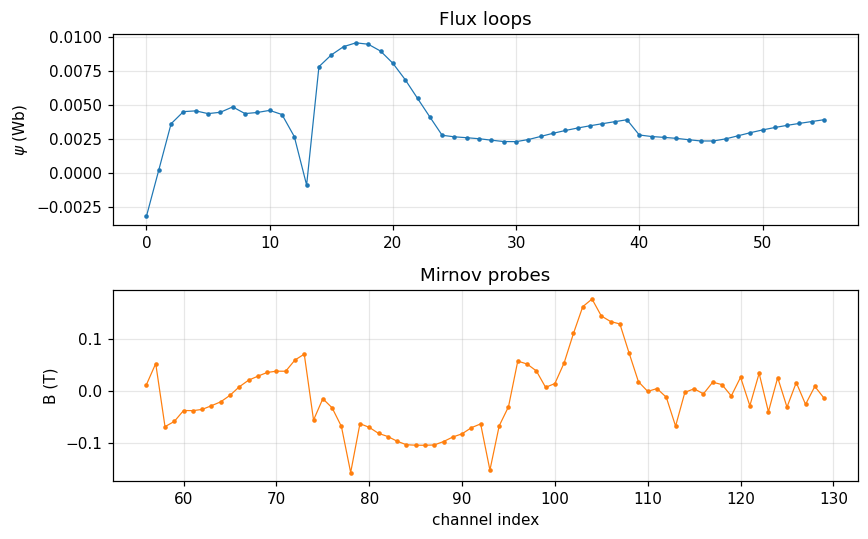

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(8.0, 5.0), sharex=False)
ax[0].plot(np.where(is_loop)[0], signals[is_loop], ".-", lw=0.8, ms=4)
ax[0].set_ylabel(r"$\psi$ (Wb)"); ax[0].set_title("Flux loops")
ax[1].plot(np.where(~is_loop)[0], signals[~is_loop], ".-", lw=0.8, ms=4, color="C1")
ax[1].set_ylabel("B (T)"); ax[1].set_xlabel("channel index"); ax[1].set_title("Mirnov probes")
for a_ in ax:
    a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### We want these signals to respond strongly to the plasma

A sensor that barely moves when the plasma changes carries no information about
it, and no reconstruction method can recover what was never measured. So before
trusting any of this, check that the signals actually track the plasma current.

We re-solve at several values of $I_p$ and record how each channel responds.

In [7]:
ip_scan = np.array([4.0e4, 7.0e4, 1.0e5, 1.3e5, 1.6e5])
scan_signals = []

for ip in ip_scan:
    mygs.set_targets(Ip=ip, Ip_ratio=4.0)
    mygs.init_psi(R0, Z0, 0.13, kappa, delta)
    mygs.solve()
    f = full_diagnostic_set(mygs, sensors)
    scan_signals.append(f[channels].to_numpy(dtype=float)[0])

scan_signals = np.array(scan_signals)
print(f"solved {len(ip_scan)} equilibria, signal matrix {scan_signals.shape}")

solved 5 equilibria, signal matrix (5, 130)


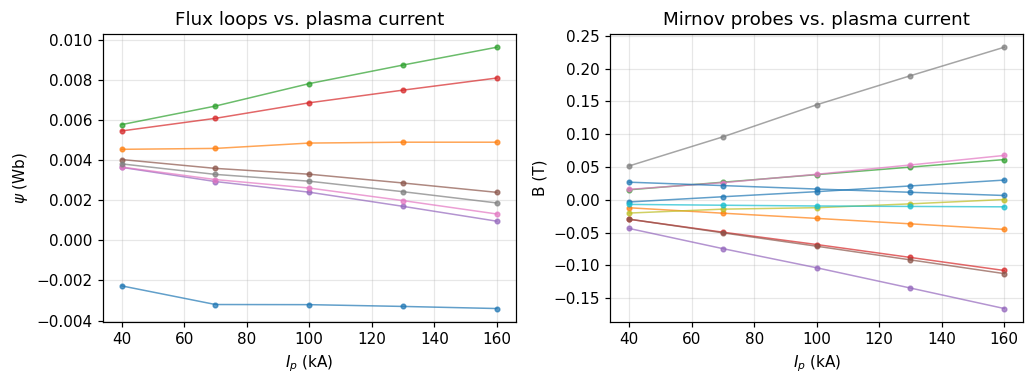

median fractional response across the Ip scan: 1.13
channels responding by less than 1%:           0 of 130


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))

for j in range(0, scan_signals.shape[1], 7):
    style = dict(lw=1.0, alpha=0.7)
    target = ax[0] if is_loop[j] else ax[1]
    target.plot(ip_scan / 1e3, scan_signals[:, j], ".-", **style)

ax[0].set_title("Flux loops vs. plasma current"); ax[0].set_ylabel(r"$\psi$ (Wb)")
ax[1].set_title("Mirnov probes vs. plasma current"); ax[1].set_ylabel("B (T)")
for a_ in ax:
    a_.set_xlabel(r"$I_p$ (kA)"); a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Fractional response of each channel across the scan.
span = np.ptp(scan_signals, axis=0)
scale = np.abs(scan_signals).mean(axis=0) + 1e-12
frac = span / scale
print(f"median fractional response across the Ip scan: {np.median(frac):.2f}")
print(f"channels responding by less than 1%:           {(frac < 0.01).sum()} of {frac.size}")

## Measurement noise

Real sensors are not exact. Digitizer resolution, integrator drift, pickup from
the coils, and calibration error all enter the measurement. The usual first
model is additive Gaussian noise scaled to each channel's own magnitude:

$$\tilde{s}_i = s_i + \epsilon_i, \qquad \epsilon_i \sim \mathcal{N}\!\left(0,\;(f\,|s_i|)^2\right)$$

with $f = 0.02$, i.e. 2% per channel.

**Caveat on the noise model, and it is the important one.** This model is
*assumed*, not measured. Real magnetic diagnostics tend to have noise that is
correlated between neighbouring channels, drifts over a shot because the
signals are integrated, and occasionally contains large isolated spikes. None
of that is Gaussian and none of it is independent per channel.

Everything downstream, including any uncertainty estimate, is conditional on
this assumption. The honest position is that a reconstruction validated here is
validated *within this noise model*, and the model should be replaced with
measured noise statistics as soon as the machine produces any.

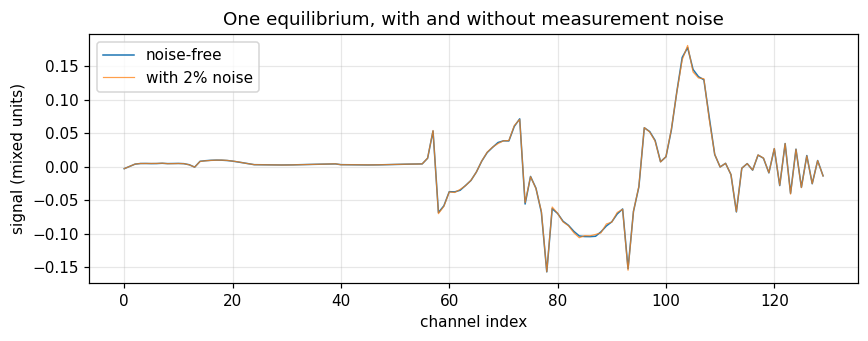

In [9]:
rng = np.random.default_rng(0)
noise_frac = 0.02

clean = scan_signals[2]                     # the Ip = 100 kA case
scale = np.maximum(np.abs(clean), 1e-12)
noisy = clean + rng.normal(0.0, 1.0, clean.shape) * (noise_frac * scale)

fig, ax = plt.subplots(1, 1, figsize=(8.0, 3.2))
idx = np.arange(clean.size)
ax.plot(idx, clean, lw=1.0, label="noise-free")
ax.plot(idx, noisy, lw=0.8, alpha=0.75, label=f"with {noise_frac:.0%} noise")
ax.set_xlabel("channel index"); ax.set_ylabel("signal (mixed units)")
ax.set_title("One equilibrium, with and without measurement noise")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### We want the noise to be small compared to the plasma-driven variation

Noise only matters relative to the signal you are trying to detect. The useful
comparison is the spread a channel shows *across different plasmas* against the
spread the noise adds to a *single* plasma. If noise dominates, that channel
cannot distinguish one equilibrium from another however clever the algorithm.

median SNR across channels :     56.6
channels with SNR < 1       :        0 of 130
channels with SNR < 10      :       12 of 130


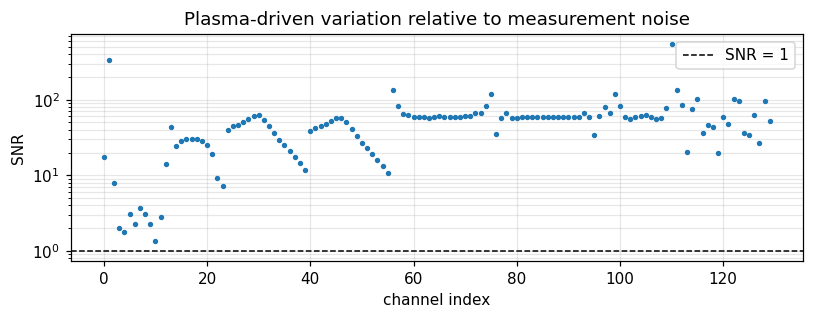

In [10]:
signal_variation = np.ptp(scan_signals, axis=0)        # across the Ip scan
noise_sigma = noise_frac * np.abs(clean)               # within one measurement
snr = signal_variation / np.maximum(noise_sigma, 1e-18)

print(f"median SNR across channels : {np.median(snr):8.1f}")
print(f"channels with SNR < 1       : {(snr < 1).sum():8d} of {snr.size}")
print(f"channels with SNR < 10      : {(snr < 10).sum():8d} of {snr.size}")

fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.0))
ax.semilogy(snr, ".", ms=5)
ax.axhline(1.0, color="k", lw=1.0, ls="--", label="SNR = 1")
ax.set_xlabel("channel index"); ax.set_ylabel("SNR")
ax.set_title("Plasma-driven variation relative to measurement noise")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

## Sensor loss

Diagnostics fail. A probe goes dead, a cable is disconnected, an integrator
saturates. Any reconstruction intended for real use has to keep working when
part of the set is missing, so the forward model needs to be able to represent
that too.

Here we simply mask a random subset of channels. What matters downstream is
that a method's accuracy is quoted *with* a dropout fraction attached, not on
the assumption that all 130 channels are always healthy.

In [11]:
def apply_dropout(signal_vec, fraction, rng):
    """Return a copy with a random `fraction` of channels zeroed, plus the mask."""
    mask = rng.random(signal_vec.shape) >= fraction
    return signal_vec * mask, mask


for frac_lost in (0.0, 0.1, 0.2):
    degraded, mask = apply_dropout(noisy, frac_lost, np.random.default_rng(1))
    print(f"dropout {frac_lost:4.0%}: {int((~mask).sum()):3d} channels lost, "
          f"{int(mask.sum()):3d} healthy")

dropout   0%:   0 channels lost, 130 healthy
dropout  10%:   9 channels lost, 121 healthy
dropout  20%:  23 channels lost, 107 healthy


## What this forward model does and does not include

Stated plainly, because every result built on it inherits these limits.

**Included:** the plasma current distribution from a converged free-boundary
Grad-Shafranov solve, the CUTE vessel and coil geometry from the mesh, exact
evaluation of $\psi$ and $\mathbf{B}$ at each sensor position, and probe
orientation.

**Not included:**

- **Integrator drift.** Real flux measurements are integrated from voltage, so
  error accumulates through a shot. A single-time-slice model cannot show this.
- **Pickup and cross-talk.** Coil currents changing during a shot induce
  signals unrelated to the plasma.
- **Calibration error.** Gains and offsets are known imperfectly, which
  produces *systematic*, not random, error.
- **Sensor finite size.** Each probe is treated as a point.
- **Three-dimensional effects.** Everything here is axisymmetric.

The gap between this list and reality is the reason a reconstruction validated
only against synthetic data is a *starting* claim, not a finished one.

## Where this leads

With a forward map in hand, the rest follows:

1. **Generate a labeled dataset.** Solve many equilibria, evaluate the sensors
   on each, and record the equilibrium's own measured parameters as labels.
   `scripts/generate_gs_dataset.py` in this repository does exactly that, and
   takes roughly 0.26 s per solve.
2. **Reconstruct.** Invert the map: signals back to plasma parameters.
3. **Learn a surrogate.** Train a model on the dataset and benchmark it against
   the classical inversion, with noise and dropout studies attached.

One point worth keeping in view when labeling such a dataset: the label must be
the equilibrium the solver **achieved**, never the one that was requested. The
sensors respond to the plasma that exists. Labeling with the request would ask
a network to predict a number its inputs do not contain, which puts a floor
under its error and quietly miscalibrates any uncertainty estimate built on top.